# Probability of Default Model using Logistic Regression

This notebook builds a baseline credit risk model using logistic regression.

The objective is to predict the probability that a borrower will experience serious delinquency within two years.

The target variable is `SeriousDlqin2yrs`.

- 0 = Non-default borrower
- 1 = Default / serious delinquency borrower

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [3]:
df = pd.read_csv("../data/raw/cs-training.csv")

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
target = "SeriousDlqin2yrs"

df[target].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In [8]:
df[target].value_counts(normalize=True) * 100

SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64

The target variable is imbalanced. Most borrowers are non-defaulters, while only a small percentage are defaulters. This is common in credit risk modelling.

In [10]:
X = df.drop(columns=[target])
y = df[target]

X.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [11]:
y.head()

0    1
1    0
2    0
3    0
4    0
Name: SeriousDlqin2yrs, dtype: int64

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (120000, 10)
Testing data shape: (30000, 10)


In [15]:
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [19]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")

log_reg.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [21]:
class_weight="balanced"

In [23]:
y_pred = log_reg.predict(X_test_scaled)

y_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1])

In [24]:
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

y_pred_proba[:10]

array([0.27555205, 0.24734206, 0.29742773, 0.31471829, 0.28096643,
       0.19210911, 0.29640917, 1.        , 0.51851863, 0.56976763])

In [26]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 77.62%


In [28]:
conf_matrix = confusion_matrix(y_test, y_pred)

conf_matrix

array([[21944,  6051],
       [  662,  1343]])

In [30]:
confusion_df = pd.DataFrame(
    conf_matrix,
    columns=["Predicted Non-Default", "Predicted Default"],
    index=["Actual Non-Default", "Actual Default"]
)

confusion_df

,Predicted Non-Default,Predicted Default
Actual Non-Default,21944,6051
Actual Default,662,1343


In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.78      0.87     27995
           1       0.18      0.67      0.29      2005

    accuracy                           0.78     30000
   macro avg       0.58      0.73      0.58     30000
weighted avg       0.92      0.78      0.83     30000



In [34]:
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.8021


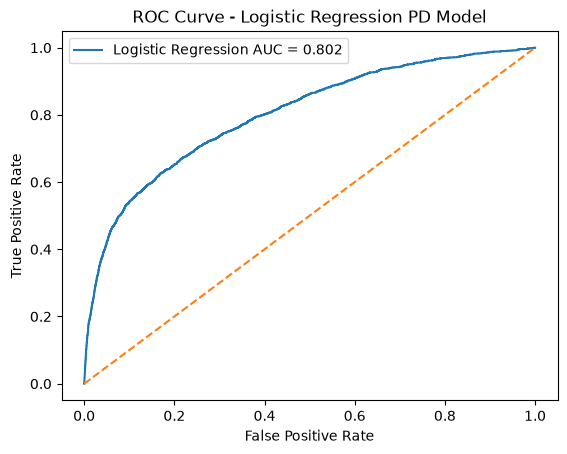

In [36]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression PD Model")
plt.legend()
plt.show()

In [37]:
results = X_test.copy()

results["Actual_Default"] = y_test
results["Predicted_Default"] = y_pred
results["Probability_of_Default"] = y_pred_proba

results.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,Actual_Default,Predicted_Default,Probability_of_Default
10682,0.019252,66,0,0.433926,5175.0,13,0,1,0,0.0,0,0,0.275552
40173,0.454221,78,0,0.873533,2300.0,7,0,1,0,2.0,0,0,0.247342
4719,0.077572,59,0,0.172882,10833.0,5,0,1,0,0.0,0,0,0.297428
81730,0.107864,59,0,0.453692,9900.0,10,0,2,0,0.0,0,0,0.314718
113639,0.101095,67,0,0.407831,5950.0,14,0,2,0,0.0,0,0,0.280966


In [38]:
def assign_risk_band(pd_value):
    if pd_value < 0.05:
        return "Low Risk"
    elif pd_value < 0.15:
        return "Medium Risk"
    elif pd_value < 0.30:
        return "High Risk"
    else:
        return "Very High Risk"

results["Risk_Band"] = results["Probability_of_Default"].apply(assign_risk_band)

results[["Actual_Default", "Predicted_Default", "Probability_of_Default", "Risk_Band"]].head()

,Actual_Default,Predicted_Default,Probability_of_Default,Risk_Band
10682,0,0,0.275552,High Risk
40173,0,0,0.247342,High Risk
4719,0,0,0.297428,High Risk
81730,0,0,0.314718,Very High Risk
113639,0,0,0.280966,High Risk


In [39]:
risk_band_summary = results.groupby("Risk_Band").agg(
    Borrower_Count=("Actual_Default", "count"),
    Actual_Default_Rate=("Actual_Default", "mean"),
    Average_PD=("Probability_of_Default", "mean")
).sort_values("Average_PD")

risk_band_summary

,Borrower_Count,Actual_Default_Rate,Average_PD
Risk_Band,,,
Low Risk,16,0.000000,0.014762
Medium Risk,144,0.013889,0.129989
High Risk,7350,0.011973,0.245953
Very High Risk,22490,0.085149,0.469890


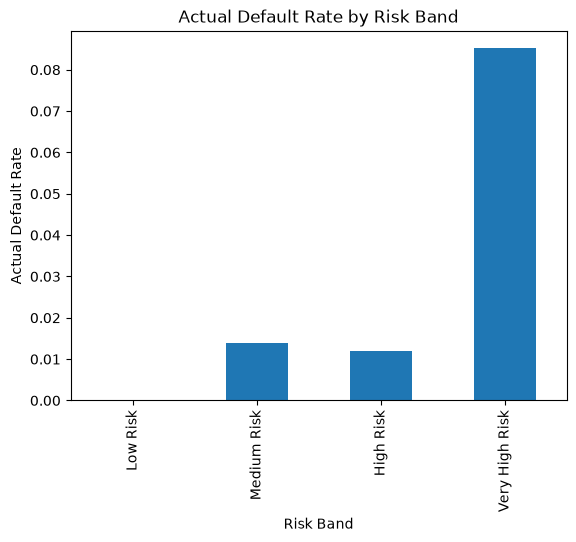

In [41]:
risk_band_summary["Actual_Default_Rate"].plot(kind="bar")

plt.title("Actual Default Rate by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Actual Default Rate")
plt.show()

In [43]:
results.to_csv("../data/processed/pd_model_predictions.csv", index=False)

## Model Interpretation

A logistic regression model was built to estimate the Probability of Default for each borrower.

The model predicts both:

1. Default class prediction
2. Probability of Default

The probability output is more useful in credit risk modelling because it allows borrowers to be ranked by risk.

Borrowers were classified into Low Risk, Medium Risk, High Risk, and Very High Risk bands based on their predicted probability of default.

The risk band analysis helps convert the model output into a business decision framework.